In [1]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os

In [2]:
face_cascade = cv2.CascadeClassifier('../Data/haarcascade_frontalface_default.xml')

In [3]:
def detect_face(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    if len(faces) == 0:
        return None

    x, y, w, h = faces[0]
    face = image[y:y + h, x:x + w]
    face = cv2.resize(face, (224, 224))
    return face

In [4]:
# Define dataset paths
train_dir = '../Data/CK+_Updated/train'
test_dir = '../Data/CK+_Updated/test'

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = ImageFolder(train_dir, transform=transform)
test_dataset = ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

In [5]:
model = models.resnet18(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 6)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\sarah/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


In [6]:
num_epochs = 10
train_acc_list = []
test_acc_list = []
train_loss_list = []
test_loss_list = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_accuracy = 100 * correct / total
    train_acc_list.append(train_accuracy)
    train_loss_list.append(running_loss / len(train_loader))

    model.eval()
    correct_test = 0
    total_test = 0
    test_loss = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total_test += labels.size(0)
            correct_test += predicted.eq(labels).sum().item()

    test_accuracy = 100 * correct_test / total_test
    test_acc_list.append(test_accuracy)
    test_loss_list.append(test_loss / len(test_loader))
    print(
        f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, '
        f'Train Accuracy: {train_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%, '
    )

Epoch [1/10], Loss: 1.7688, Train Accuracy: 27.63%, Test Accuracy: 34.02%, 
Epoch [2/10], Loss: 0.8289, Train Accuracy: 76.75%, Test Accuracy: 56.70%, 
Epoch [3/10], Loss: 0.4435, Train Accuracy: 90.35%, Test Accuracy: 62.89%, 
Epoch [4/10], Loss: 0.2841, Train Accuracy: 95.18%, Test Accuracy: 68.04%, 
Epoch [5/10], Loss: 0.1724, Train Accuracy: 98.68%, Test Accuracy: 72.16%, 
Epoch [6/10], Loss: 0.0892, Train Accuracy: 100.00%, Test Accuracy: 76.29%, 
Epoch [7/10], Loss: 0.0507, Train Accuracy: 100.00%, Test Accuracy: 79.38%, 
Epoch [8/10], Loss: 0.0311, Train Accuracy: 100.00%, Test Accuracy: 79.38%, 
Epoch [9/10], Loss: 0.0240, Train Accuracy: 100.00%, Test Accuracy: 79.38%, 
Epoch [10/10], Loss: 0.0165, Train Accuracy: 100.00%, Test Accuracy: 79.38%, 


Final Test Accuracy: 79.38%


<Figure size 800x600 with 0 Axes>

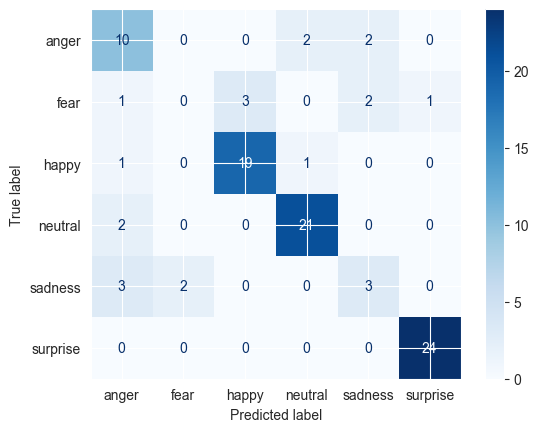

In [7]:
model.eval()
y_true = []
y_pred = []
total = 0
correct = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

final_test_accuracy = 100 * correct / total
print(f'Final Test Accuracy: {final_test_accuracy:.2f}%')

confusion_matrix = confusion_matrix(y_true, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix, display_labels=test_dataset.classes)

plt.figure(figsize=(8, 6))
cm_display.plot(cmap=plt.cm.Blues)
plt.show()

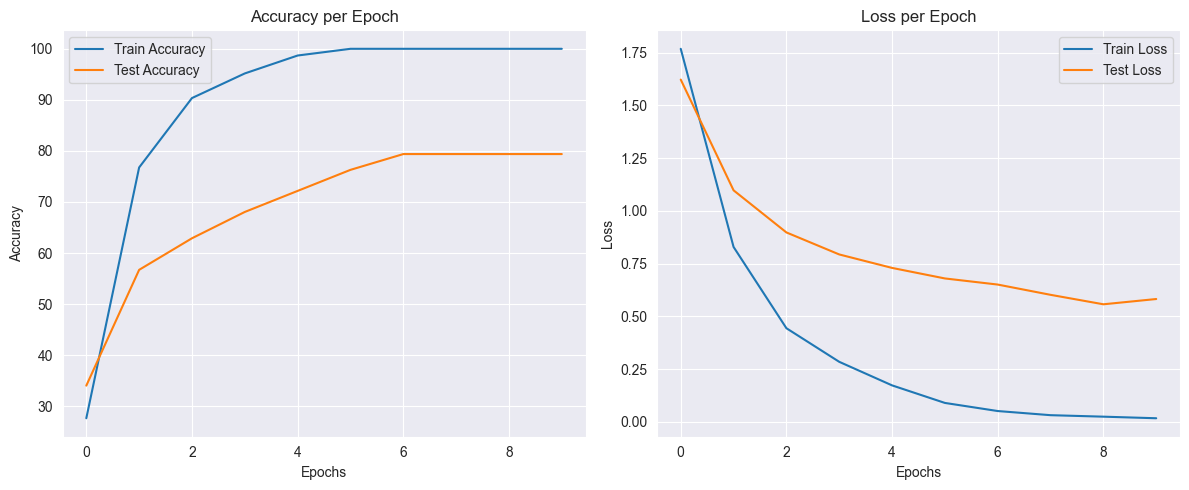

In [8]:
# Plot Accuracy and Loss
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(train_acc_list, label='Train Accuracy')
plt.plot(test_acc_list, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy per Epoch')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(test_loss_list, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss per Epoch')

plt.tight_layout()
plt.show()

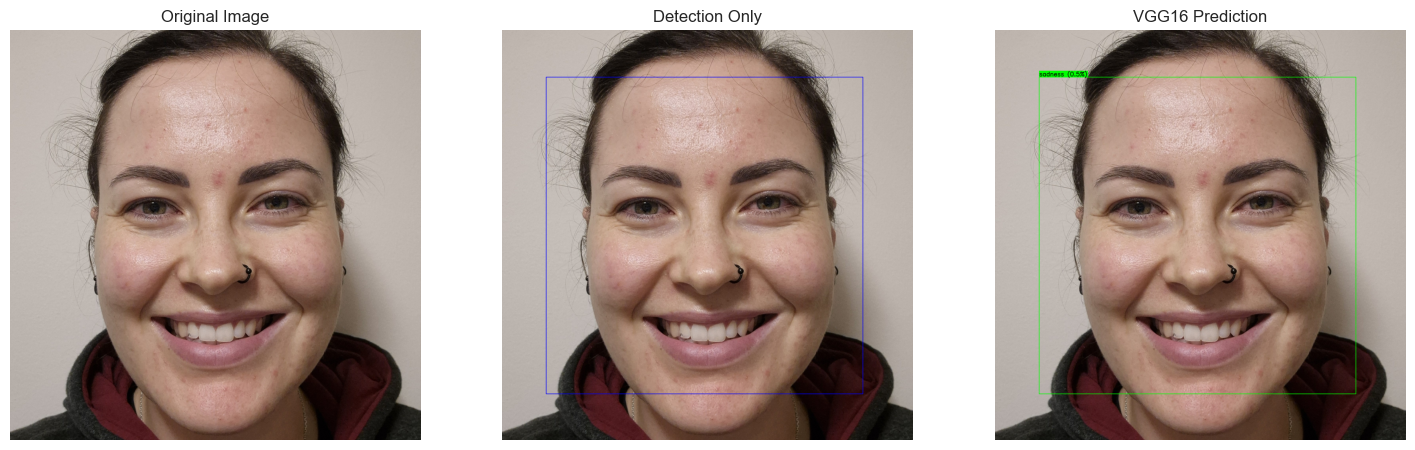

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_height, img_width = 224, 224

expressions = ['anger', 'fear', 'happy', 'neutral', 'sadness', 'surprise']

def preprocess_face(face_bgr):
    face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)

    face_resized = cv2.resize(face_rgb, (img_height, img_width))

    face_tensor = torch.from_numpy(face_resized).float() / 255.0
    face_tensor = face_tensor.permute(2, 0, 1)  # Change HWC to CHW

    face_batch = face_tensor.unsqueeze(0)

    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    face_batch = normalize(face_batch)

    return face_batch

# Path to the test image
img_path = '../Data/assignment/CK_dataset/happy/20251201_195833.jpg'
#img_path = '../Data/assignment/CK_dataset/neutral/20251201_200909.jpg'

original_img = cv2.imread(img_path)
if original_img is None:
    print(f"Error: Could not load image at {img_path}")
else:
    gray_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray_img, scaleFactor=1.3, minNeighbors=5)

    face_detected_img = original_img.copy()
    final_img = original_img.copy()

    for (x, y, w, h) in faces:
        face_roi = original_img[y:y+h, x:x+w]

        # ... inside the loop ...
        processed_face = preprocess_face(face_roi)

        # Ensure model is in eval mode and move tensor to same device as model
        model.eval()
        device = next(model.parameters()).device
        processed_face = processed_face.to(device)

        with torch.no_grad():
            output = model(processed_face)
            probs = torch.softmax(output, dim=1)

            # Get the index of the highest probability
            prediction_idx = torch.argmax(probs, dim=1).item()
            confidence = probs[0][prediction_idx].item()

            # Map index to emotion string
            predicted_emotion = expressions[prediction_idx]

        # Now proceed to draw your rectangles and labels...

        cv2.rectangle(face_detected_img, (x, y), (x + w, y + h), (255, 0, 0), 2)
        cv2.rectangle(final_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

        label = f"{predicted_emotion} ({confidence:.1f}%)"
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 1.0
        font_thickness = 2

        (text_width, text_height), _ = cv2.getTextSize(label, font, font_scale, font_thickness)
        cv2.rectangle(final_img, (x, y - text_height - 10), (x + text_width, y), (0, 255, 0), -1)
        cv2.putText(final_img, label, (x, y - 5), font, font_scale, (0, 0, 0), font_thickness)

    original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    face_detected_img_rgb = cv2.cvtColor(face_detected_img, cv2.COLOR_BGR2RGB)
    final_img_rgb = cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(original_img_rgb)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(face_detected_img_rgb)
    axes[1].set_title("Detection Only")
    axes[1].axis("off")

    axes[2].imshow(final_img_rgb)
    axes[2].set_title("ResNet18 Prediction")
    axes[2].axis("off")

    plt.show()